13. This question should be answered using the Weekly data set, which</br>
is part of the ISLP package. This data is similar in nature to the</br>
Smarket data from this chapter’s lab, except that it contains 1, 089</br>
weekly returns for 21 years, from the beginning of 1990 to the end of</br>
2010.</br>

(a) Produce some numerical and graphical summaries of the Weekly
data. Do there appear to be any patterns?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [2]:
from ISLP import load_data
weekly = load_data('Weekly')
weekly

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up
...,...,...,...,...,...,...,...,...,...
1084,2010,-0.861,0.043,-2.173,3.599,0.015,3.205160,2.969,Up
1085,2010,2.969,-0.861,0.043,-2.173,3.599,4.242568,1.281,Up
1086,2010,1.281,2.969,-0.861,0.043,-2.173,4.835082,0.283,Up
1087,2010,0.283,1.281,2.969,-0.861,0.043,4.454044,1.034,Up


In [3]:
# 檢視基本資訊
print(weekly.head())
print(weekly.describe())
print(weekly['Direction'].value_counts())

   Year   Lag1   Lag2   Lag3   Lag4   Lag5    Volume  Today Direction
0  1990  0.816  1.572 -3.936 -0.229 -3.484  0.154976 -0.270      Down
1  1990 -0.270  0.816  1.572 -3.936 -0.229  0.148574 -2.576      Down
2  1990 -2.576 -0.270  0.816  1.572 -3.936  0.159837  3.514        Up
3  1990  3.514 -2.576 -0.270  0.816  1.572  0.161630  0.712        Up
4  1990  0.712  3.514 -2.576 -0.270  0.816  0.153728  1.178        Up
              Year         Lag1         Lag2         Lag3         Lag4  \
count  1089.000000  1089.000000  1089.000000  1089.000000  1089.000000   
mean   2000.048669     0.150585     0.151079     0.147205     0.145818   
std       6.033182     2.357013     2.357254     2.360502     2.360279   
min    1990.000000   -18.195000   -18.195000   -18.195000   -18.195000   
25%    1995.000000    -1.154000    -1.154000    -1.158000    -1.158000   
50%    2000.000000     0.241000     0.241000     0.241000     0.238000   
75%    2005.000000     1.405000     1.409000     1.409000     

| 變數名稱          | 類型 | 意義                   |
| ------------- | -- | -------------------- |
| **Year**      | 數值 | 年份 (1990–2005)       |
| **Lag1**      | 數值 | 昨日報酬率 (%)            |
| **Lag2**      | 數值 | 前兩日報酬率 (%)           |
| **Lag3**      | 數值 | 前三日報酬率 (%)           |
| **Lag4**      | 數值 | 前四日報酬率 (%)           |
| **Lag5**      | 數值 | 前五日報酬率 (%)           |
| **Volume**    | 數值 | 交易量 (以十億為單位)         |
| **Today**     | 數值 | 今日報酬率 (%)            |
| **Direction** | 類別 | 今日市場走勢：`Up` 或 `Down` |


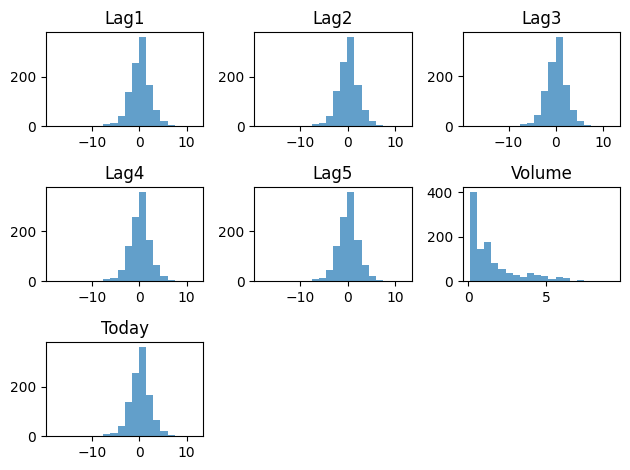

In [4]:
# 是否近似常態分布（Normal-like）
# 把所有年份的 Lag1 數值混在一起，看「這個變數的值最常落在哪個範圍」。
for i, column in enumerate(['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Today']):
    plt.subplot(3, 3, i + 1)
    plt.hist(weekly[column], bins=20, alpha=0.7)
    plt.title(column)
# Histogram 檢查分佈與離群值
plt.tight_layout()
plt.show()

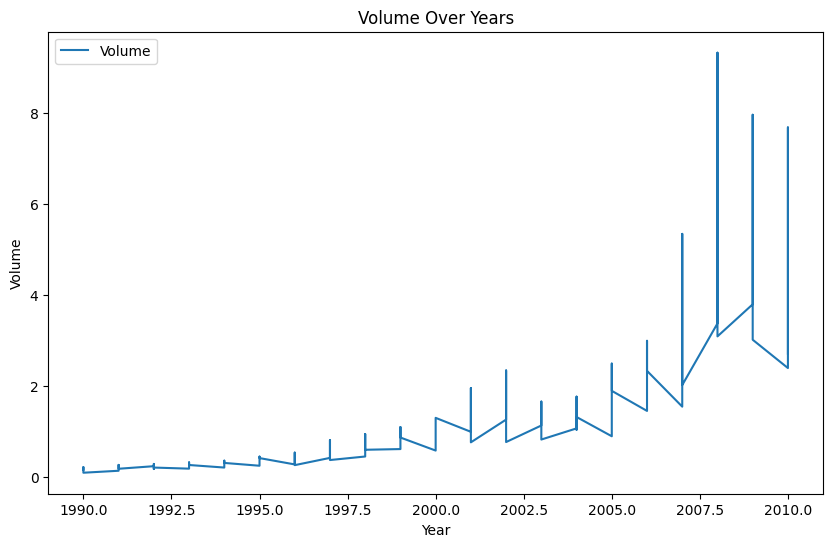

In [5]:
# Volume 時間變化趨勢圖
plt.figure(figsize=(10, 6))
plt.plot(weekly['Year'], weekly['Volume'], label='Volume') #繪製折線圖
plt.title("Volume Over Years")
plt.xlabel("Year")
plt.ylabel("Volume")
plt.legend()
plt.show()

股票市場的交易量（Volume）在 1990 到 2010 年之間持續上升，且後期波動更大。

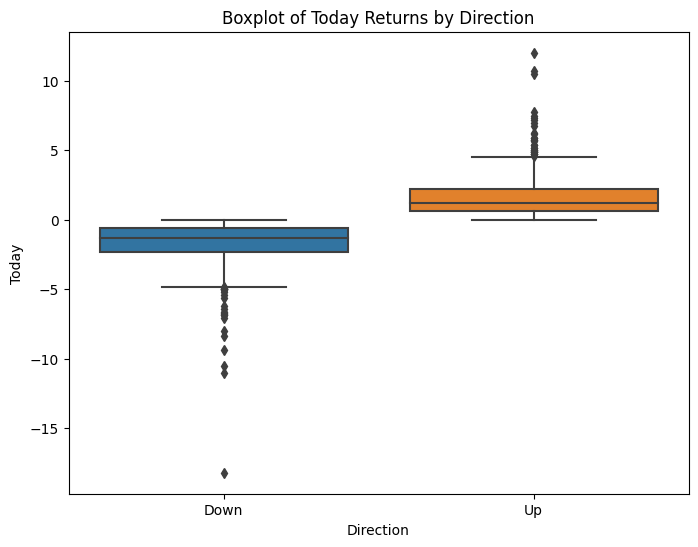

In [6]:
# 根據 Direction 分組的 Boxplot（箱型圖）
# 觀察「漲跌方向」(Direction = Up/Down) 與「當週報酬率」(Today) 的關係。
plt.figure(figsize=(8, 6))
sns.boxplot(x='Direction', y='Today', data=weekly)
plt.title("Boxplot of Today Returns by Direction")
plt.show()

# 方盒底線	第一四分位數 (Q1, 25%)	有 25% 資料低於這個值
# 方盒頂線	第三四分位數 (Q3, 75%)	有 75% 資料低於這個值

| 圖形元素         | 統計意義                             | 在你的圖中代表                                                        |
| ------------ | -------------------------------- | -------------------------------------------------------------- |
| **中間的橫線**    | 中位數 (Median)                     | Up 約在 +1%；Down 約在 -1%。代表上漲週平均報酬為正，下跌週為負。                       |
| **盒子的上下邊緣**  | Q1 (25%) 與 Q3 (75%) → 四分位距 (IQR) | 代表中間 50% 的資料。<br>Up 組在約 0～2% 間；Down 組在約 -3～0% 間。               |
| **盒子的高度**    | IQR（數據離散程度）                      | 兩組 IQR 大小相近 → 報酬率波動幅度差不多。                                      |
| **上下延伸的「鬚」** | 資料範圍內的最小/最大值（不含離群值）              | 表示大部分報酬率落在這個範圍內。Down 的下鬚更長 → 下跌週的負報酬較極端。                       |
| **散落在鬚外的點**  | 離群值 (Outliers)                   | 這些是特別大的漲幅或跌幅的週。你可以看到 Up 組有幾個 +10% 的週，而 Down 組有幾個 -10%～-17% 的週。 |


(b) Use the full data set to perform a logistic regression with</br>
Direction as the response and the five lag variables plus Volume</br>
as predictors. Use the summary function to print the results. Do</br>
any of the predictors appear to be statistically significant? If so,</br>
which ones?</br>
Y：Direction（市場方向 Up/Down）</br>
X：Lag1, Lag2, Lag3, Lag4, Lag5, Volume</br>

In [7]:
import statsmodels.api as sm

# 轉換方向為數值 (Up=1, Down=0)
weekly['Direction'] = (weekly['Direction'] == 'Up').astype(int)

# 自變數
X = weekly[['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume']]
X = sm.add_constant(X)  # 加入截距項

# 應變數
y = weekly['Direction']

# 建立 logistic regression 模型
model = sm.Logit(y, X)
result = model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.682441
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:              Direction   No. Observations:                 1089
Model:                          Logit   Df Residuals:                     1082
Method:                           MLE   Df Model:                            6
Date:                Sun, 09 Nov 2025   Pseudo R-squ.:                0.006580
Time:                        23:37:36   Log-Likelihood:                -743.18
converged:                       True   LL-Null:                       -748.10
Covariance Type:            nonrobust   LLR p-value:                    0.1313
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2669      0.086      3.106      0.002       0.098       0.435
Lag1          -0.0413      0.

logistic regression summary 特別注意的地方
| 欄位                          | 意義                   | 可觀察到的資料特徵                              |
| --------------------------- | -------------------- | -------------------------------------- |
| **Dep. Variable**           | 因變數（這裡是 `Direction`） | 你要預測的對象是漲跌方向。                          |
| **No. Observations**        | 資料筆數                 | 確認樣本大小（太小容易不顯著）。                       |
| **Df Residuals / Df Model** | 自由度（樣本數 - 變數數）       | 可看變數多不多、模型是否過度擬合。                      |
| **Method: MLE**             | 最大概似法                | Logistic regression 標準估計方法。            |
| **Pseudo R-squ.**           | 類似 R²（但不等於）          | 越高代表模型越能區分 Up/Down。這裡很低 → 模型解釋力弱。      |
| **LLR p-value**             | 整體模型顯著性檢定            | 若 p < 0.05 → 模型整體顯著；這裡 0.93 → 模型無顯著關係。 |

p=0.13 > 0.05 → 模型整體 不顯著，說明整體預測能力弱
Pseudo R² ≈ 0.0066 模型預測力極低

(c) Compute the confusion matrix and overall fraction of correct</br>
predictions. Explain what the confusion matrix is telling you</br>
about the types of mistakes made by logistic regression.</br>

In [8]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Predict probabilities of logistic regression model
predicted_probabilities = result.predict(X)

# 使用 0.5 作為 threshold
predicted_classes = [1 if prob > 0.5 else 0 for prob in predicted_probabilities]

# Compute the confusion matrix and overall accuracy
conf_matrix = confusion_matrix(y, predicted_classes)
accuracy = accuracy_score(y, predicted_classes)

# Print the confusion matrix and accuracy
print("Confusion Matrix:")
print(conf_matrix)
print("\nOverall Accuracy:", accuracy)

Confusion Matrix:
[[ 54 430]
 [ 48 557]]

Overall Accuracy: 0.5610651974288338


|                     | **Predicted Down (0)** | **Predicted Up (1)** |
| ------------------- | ---------------------- | -------------------- |
| **Actual Down (0)** | TN = 54                | FP = 430             |
| **Actual Up (1)**   | FN = 48                | TP = 557             |

TN (True Negative) | 模型正確預測為下跌 | 54  | 模型預測「Down」且實際也 Down </br>
FP (False Positive) | 錯誤預測為上漲   | 430 | 模型預測「Up」但實際是 Down</br>
FN (False Negative) | 錯誤預測為下跌   | 48  | 模型預測「Down」但實際是 Up</br>
TP (True Positive)  | 模型正確預測為上漲 | 557 | 模型預測「Up」且實際也 Up</br>



(d) Now fit the logistic regression model using a training data period</br>
from 1990 to 2008, with Lag2 as the only predictor. Compute the</br>
confusion matrix and the overall fraction of correct predictions</br>
for the held out data (that is, the data from 2009 and 2010).</br>

In [9]:
# Split the dataset into training (1990-2008) and testing (2009-2010) sets
train_data = weekly[weekly['Year'] <= 2008]
test_data = weekly[weekly['Year'] > 2008]

# the only predictor Lag2
X_train = train_data[['Lag2']]
X_train = sm.add_constant(X_train)
y_train = train_data['Direction']

X_test = test_data[['Lag2']]
X_test = sm.add_constant(X_test) 
y_test = test_data['Direction']

# Fit logistic regression model on the training data
model_lag2 = sm.Logit(y_train, X_train)
result_lag2 = model_lag2.fit()

# Predict probabilities for the test set
predicted_probabilities_lag2 = result_lag2.predict(X_test)

# Convert probabilities to binary predictions (using threshold 0.5)
predicted_classes_lag2 = [1 if prob > 0.5 else 0 for prob in predicted_probabilities_lag2]

# Compute the confusion matrix and overall accuracy for the test set
conf_matrix_lag2 = confusion_matrix(y_test, predicted_classes_lag2)
accuracy_lag2 = accuracy_score(y_test, predicted_classes_lag2)

# Print results
print("Confusion Matrix for Test Set:")
print(conf_matrix_lag2)
print("\nOverall Accuracy for Test Set:", accuracy_lag2)


Optimization terminated successfully.
         Current function value: 0.685555
         Iterations 4
Confusion Matrix for Test Set:
[[ 9 34]
 [ 5 56]]

Overall Accuracy for Test Set: 0.625


|                     | **Predicted Down (0)** | **Predicted Up (1)** |
| ------------------- | ---------------------- | -------------------- |
| **Actual Down (0)** | TN = 9                 | FP = 34              |
| **Actual Up (1)**   | FN = 5                 | TP = 56              |

</br>

| 指標                     | 計算公式                            | 結果                                       | 意義                          |
| ---------------------- | ------------------------------- | ---------------------------------------- | --------------------------- |
| **Accuracy**           | (TP + TN) / (TN + FP + FN + TP) | (56 + 9) / (9 + 34 + 5 + 56) = **0.625** | 模型正確率 = 62.5%，略優於隨機猜測 (50%) |
| **Precision (Up)**     | TP / (TP + FP)                  | 56 / (56 + 34) = 0.622                   | 模型預測為「Up」時，有 62.2% 真的是上漲週   |
| **Recall (Up)**        | TP / (TP + FN)                  | 56 / (56 + 5) = 0.918                    | 模型捕捉到 91.8% 的上漲週（很敏感）       |
| **Specificity (Down)** | TN / (TN + FP)                  | 9 / (9 + 34) = 0.209                     | 僅正確預測到 21% 的下跌週（預測 Down 很差） |


(e) Repeat (d) using LDA. LinearDiscriminantAnalysis

Confusion Matrix for Test Set (LDA):
[[ 9 34]
 [ 5 56]]

Overall Accuracy for Test Set (LDA): 0.625


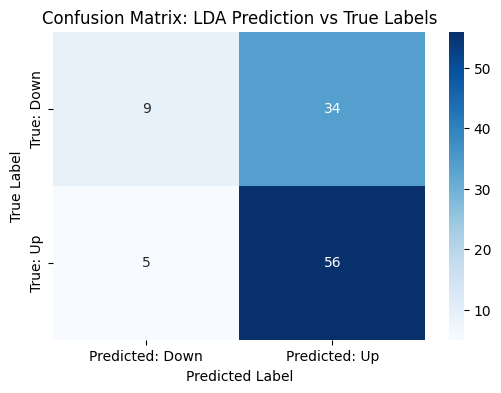

In [11]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, accuracy_score

# 分割資料
train_data = weekly[weekly['Year'] <= 2008]
test_data  = weekly[weekly['Year'] > 2008]

X_train = train_data[['Lag2']]
y_train = train_data['Direction']
X_test  = test_data[['Lag2']]
y_test  = test_data['Direction']

# 建立與訓練 LDA 模型
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train, y_train)

# 預測機率
predicted_probabilities_lda = lda_model.predict_proba(X_test)
# print(predicted_probabilities_lda[:5])  # 前五筆機率

# 自動分類結果（內部閾值 = 0.5）
predicted_classes_lda = lda_model.predict(X_test)

# 混淆矩陣與準確率
conf_matrix_lda = confusion_matrix(y_test, predicted_classes_lda)
accuracy_lda = accuracy_score(y_test, predicted_classes_lda)

print("Confusion Matrix for Test Set (LDA):")
print(conf_matrix_lda)
print("\nOverall Accuracy for Test Set (LDA):", accuracy_lda)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix_lda, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Down','Predicted: Up'],
            yticklabels=['True: Down','True: Up'])

plt.title('Confusion Matrix: LDA Prediction vs True Labels')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


| 模型      | 假設的決策邊界        | 模型假設           | 說明           |
| ------- | -------------- | -------------- | ------------ |
| **LDA** | 線性 (Linear)    | 各類別共用相同協方差矩陣   | 建立一條直線分界     |
| **QDA** | 二次 (Quadratic) | 各類別各自擁有不同協方差矩陣 | 可以畫出曲線分界，更靈活 |


(f) Repeat (d) using QDA.

Confusion Matrix for Test Set (QDA):
[[ 0 43]
 [ 0 61]]

Overall Accuracy for Test Set (QDA): 0.5865384615384616


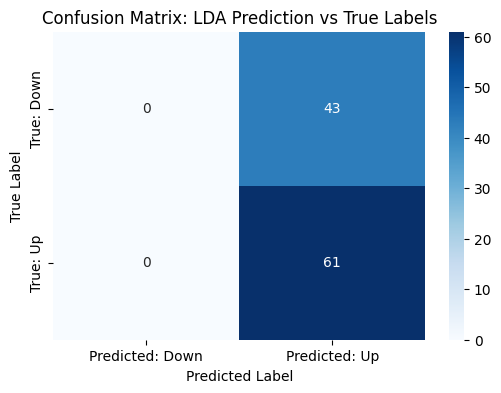

In [12]:
# 匯入需要的套件
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, accuracy_score

train_data = weekly[weekly['Year'] <= 2008]
test_data  = weekly[weekly['Year'] > 2008]

X_train = train_data[['Lag2']]
y_train = train_data['Direction']

X_test  = test_data[['Lag2']]
y_test  = test_data['Direction']

# 建立並訓練 QDA 模型
qda_model = QuadraticDiscriminantAnalysis()
qda_model.fit(X_train, y_train)

# 在測試集上進行預測
predicted_classes_qda = qda_model.predict(X_test)

# QDA 預測機率
# print(qda_model.predict_proba(X_test)[:5])

# 計算混淆矩陣與準確率
conf_matrix_qda = confusion_matrix(y_test, predicted_classes_qda)
accuracy_qda = accuracy_score(y_test, predicted_classes_qda)

print("Confusion Matrix for Test Set (QDA):")
print(conf_matrix_qda)
print("\nOverall Accuracy for Test Set (QDA):", accuracy_qda)
# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix_qda, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Down','Predicted: Up'],
            yticklabels=['True: Down','True: Up'])

plt.title('Confusion Matrix: LDA Prediction vs True Labels')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


(g) Repeat (d) using KNN with K = 1.

Confusion Matrix for Test Set (KNN, k=1):
[[21 22]
 [30 31]]

Overall Accuracy for Test Set (KNN, k=1): 0.5


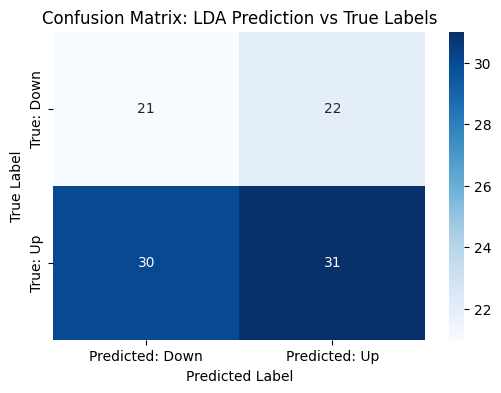

In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

train_data = weekly[weekly['Year'] <= 2008]
test_data  = weekly[weekly['Year'] > 2008]

X_train = train_data[['Lag2']]
y_train = train_data['Direction']

X_test  = test_data[['Lag2']]
y_test  = test_data['Direction']

# KNN 對距離非常敏感 → 標準化變數（重要！）
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled  = scaler.transform(X_test)


# 建立並訓練 KNN 模型（例如 k=1）
knn_model = KNeighborsClassifier(n_neighbors=1)
knn_model.fit(X_train, y_train)

# 預測與評估
predicted_classes_knn = knn_model.predict(X_test)

conf_matrix_knn = confusion_matrix(y_test, predicted_classes_knn)
accuracy_knn = accuracy_score(y_test, predicted_classes_knn)

print("Confusion Matrix for Test Set (KNN, k=1):")
print(conf_matrix_knn)
print("\nOverall Accuracy for Test Set (KNN, k=1):", accuracy_knn)
# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Down','Predicted: Up'],
            yticklabels=['True: Down','True: Up'])

plt.title('Confusion Matrix: LDA Prediction vs True Labels')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

(h) Repeat (d) using naive Bayes.

Confusion Matrix for Test Set (KNN, k=1):
[[ 0 43]
 [ 0 61]]

Overall Accuracy for Test Set (KNN, k=1): 0.5865384615384616


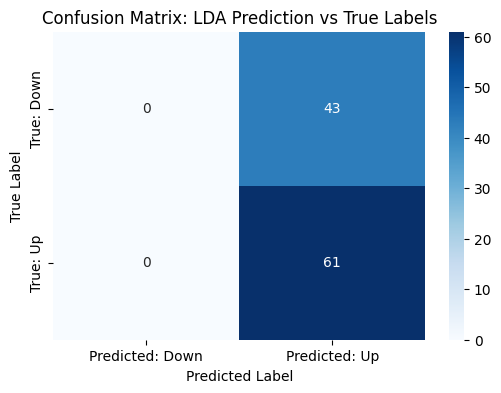

In [14]:
from sklearn.naive_bayes import GaussianNB

train_data = weekly[weekly['Year'] <= 2008]
test_data  = weekly[weekly['Year'] > 2008]

X_train = train_data[['Lag2']]
y_train = train_data['Direction']

X_test  = test_data[['Lag2']]
y_test  = test_data['Direction']


nb = GaussianNB()
nb.fit(X_train, y_train)
predictions_nb = nb.predict(X_test)
conf_matrix_nb = confusion_matrix(y_test, predictions_nb)
accuracy_nb = accuracy_score(y_test, predictions_nb)

print("Confusion Matrix for Test Set (KNN, k=1):")
print(conf_matrix_nb)
print("\nOverall Accuracy for Test Set (KNN, k=1):", accuracy_nb)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Down','Predicted: Up'],
            yticklabels=['True: Down','True: Up'])

plt.title('Confusion Matrix: LDA Prediction vs True Labels')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

(i) Which of these methods appears to provide the best results on this data?
</br>
    <p>Logit and LDA method is best because of its hight accuracy. > 0.6 accuracy

(j) Experiment with different combinations of predictors, includ-</br>
ing possible transformations and interactions, for each of the</br>
methods. Report the variables, method, and associated confu-</br>
sion matrix that appears to provide the best results on the held</br>
out data. Note that you should also experiment with values for</br>
K in the KNN classifier.</br> 實驗不同的變數組合與方法，找出在測試資料上表現最好的模型


=== Logistic Regression ===
                           Logit Regression Results                           
Dep. Variable:              Direction   No. Observations:                  985
Model:                          Logit   Df Residuals:                      980
Method:                           MLE   Df Model:                            4
Date:                Sun, 09 Nov 2025   Pseudo R-squ.:                0.006888
Time:                        23:42:20   Log-Likelihood:                -672.69
converged:                       True   LL-Null:                       -677.35
Covariance Type:            nonrobust   LLR p-value:                   0.05333
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1825      0.069      2.653      0.008       0.048       0.317
Lag1          -0.0486      0.031     -1.569      0.117      -0.109       0.012
Lag2           0.0600  

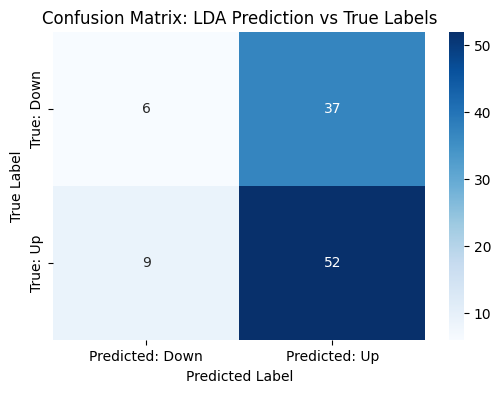

In [15]:
# 試不同模型（Logistic / LDA / QDA / KNN）
# 改變自變數組合（例如 Lag1~Lag5、Volume、或加交互項、平方項）
# 測試不同 K 值（在 KNN 中）
# 比較每個模型在測試資料上的 Confusion Matrix 與 Accuracy
# 選出表現最好的模型與變數組合
# ==============================================
# ISLR - Weekly Dataset (Question j)
# Model comparison: Logistic, LDA, QDA, KNN
# ==============================================

import statsmodels.api as sm
import pandas as pd
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score

train = weekly[weekly['Year'] <= 2008].copy()
test  = weekly[weekly['Year'] > 2008].copy()

y_train = train['Direction']
y_test  = test['Direction']

# =====================================================
# Logistic Regression (baseline + interaction terms)
# =====================================================
train['Lag1_Lag2'] = train['Lag1'] * train['Lag2']
train['Lag2_sq'] = train['Lag2'] ** 2
test['Lag1_Lag2'] = test['Lag1'] * test['Lag2']
test['Lag2_sq'] = test['Lag2'] ** 2

X_train_logit = sm.add_constant(train[['Lag1', 'Lag2', 'Lag1_Lag2', 'Lag2_sq']])
X_test_logit  = sm.add_constant(test[['Lag1', 'Lag2', 'Lag1_Lag2', 'Lag2_sq']])

model_logit = sm.Logit(y_train, X_train_logit).fit(disp=False)
y_pred_logit = (model_logit.predict(X_test_logit) > 0.5).astype(int)
conf_logit = confusion_matrix(y_test, y_pred_logit)
acc_logit = accuracy_score(y_test, y_pred_logit)

print("\n=== Logistic Regression ===")
print(model_logit.summary())
print("Confusion Matrix:\n", conf_logit)
print("Accuracy:", round(acc_logit, 3))
# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(conf_logit, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Down','Predicted: Up'],
            yticklabels=['True: Down','True: Up'])

plt.title('Confusion Matrix: LDA Prediction vs True Labels')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()



=== Linear Discriminant Analysis (LDA) ===
Confusion Matrix:
 [[27 16]
 [33 28]]
Accuracy: 0.529


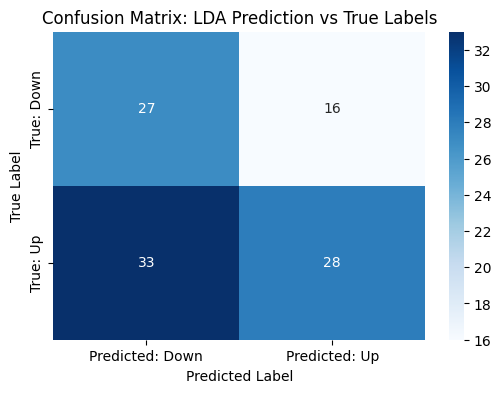

In [16]:
# LDA
lda = LinearDiscriminantAnalysis()
X_train_lda = train[['Lag1', 'Lag2', 'Volume']]
X_test_lda  = test[['Lag1', 'Lag2', 'Volume']]

lda.fit(X_train_lda, y_train)
y_pred_lda = lda.predict(X_test_lda)
conf_lda = confusion_matrix(y_test, y_pred_lda)
acc_lda = accuracy_score(y_test, y_pred_lda)

print("\n=== Linear Discriminant Analysis (LDA) ===")
print("Confusion Matrix:\n", conf_lda)
print("Accuracy:", round(acc_lda, 3))
# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(conf_lda, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Down','Predicted: Up'],
            yticklabels=['True: Down','True: Up'])

plt.title('Confusion Matrix: LDA Prediction vs True Labels')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


=== Quadratic Discriminant Analysis (QDA) ===
Confusion Matrix:
 [[32 11]
 [44 17]]
Accuracy: 0.471


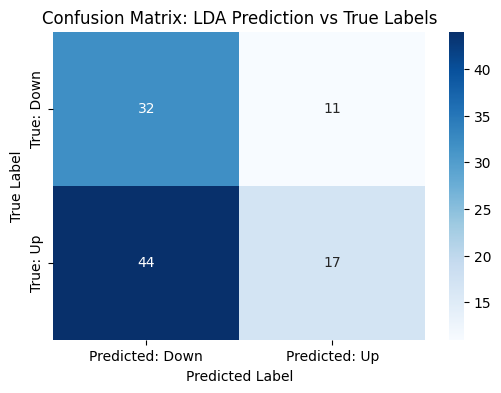

In [17]:
# QDA
qda = QuadraticDiscriminantAnalysis()
X_train_qda = train[['Lag2', 'Volume']]
X_test_qda  = test[['Lag2', 'Volume']]

qda.fit(X_train_qda, y_train)
y_pred_qda = qda.predict(X_test_qda)
conf_qda = confusion_matrix(y_test, y_pred_qda)
acc_qda = accuracy_score(y_test, y_pred_qda)

print("\n=== Quadratic Discriminant Analysis (QDA) ===")
print("Confusion Matrix:\n", conf_qda)
print("Accuracy:", round(acc_qda, 3))
# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(conf_qda, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Down','Predicted: Up'],
            yticklabels=['True: Down','True: Up'])

plt.title('Confusion Matrix: LDA Prediction vs True Labels')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
# KNN
scaler = StandardScaler()
X_train_knn = scaler.fit_transform(train[['Lag2', 'Volume']])
X_test_knn  = scaler.transform(test[['Lag2', 'Volume']])

print("\n=== K-Nearest Neighbors (KNN) ===")
for k in [1, 3, 5, 10, 20]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_knn, y_train)
    y_pred_knn = knn.predict(X_test_knn)
    conf_knn = confusion_matrix(y_test, y_pred_knn)
    acc_knn = accuracy_score(y_test, y_pred_knn)
    print(f"\nK = {k}")
    print("Confusion Matrix:\n", conf_knn)
    print("Accuracy:", round(acc_knn, 3))
    



=== K-Nearest Neighbors (KNN) ===

K = 1
Confusion Matrix:
 [[25 18]
 [33 28]]
Accuracy: 0.51

K = 3
Confusion Matrix:
 [[30 13]
 [38 23]]
Accuracy: 0.51

K = 5
Confusion Matrix:
 [[26 17]
 [30 31]]
Accuracy: 0.548

K = 10
Confusion Matrix:
 [[33 10]
 [33 28]]
Accuracy: 0.587

K = 20
Confusion Matrix:
 [[35  8]
 [42 19]]
Accuracy: 0.519
